# 02_타겟정의 — 급증·급감 라벨 생성, 25조합 민감도, 분할 배치, 이벤트 스터디

**목적:** §6 롤링 윈도우 타겟을 L3 282개에 구현하고, 채택 기준 **(변화율 ±20% AND |Δ| ≥ 10백만원 — 2026-07-16 사용자 확정)**을 25개 대안 조합과 비교해 정당화한다. 기준월별 분포·전이 행렬·이벤트 스터디로 라벨의 시간 안정성과 비즈니스 의미를 검증한다.

**입력:** `data/raw/데이터.parquet`, `data/processed/L3_법인목록.parquet` (01_EDA 산출 — 재계산 금지)

**출력:** `data/processed/라벨_L3.parquet`(구간 배치 포함), `outputs/figures/02_*.png`, `outputs/tables/02_*.csv`

**타겟 정의(§6):** 기준월 t(202304~202509, 30개)마다 past = mean(카드, t−2…t), future = mean(t+1…t+3), Δ = future − past, 변화율 = Δ/past. 급증 = (변화율 ≥ +20%) AND (Δ ≥ +10), 급감 = (변화율 ≤ −20%) AND (Δ ≤ −10), 유지 = 그 외.

**분할(§7):** Train 202304~202403(12) / Embargo 202404~202405(제외) / Holdout-Valid 202406~202411(6) / Holdout-Test 202412~202509(10). Train만 팀 확정값이며 나머지는 라벨 윈도우 비중첩 논리로 도출한 제안값.

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import common
from common import (IM, LABEL_COLOR, SEED, ID, YM, CARD,
                    set_korean_font, load_data, load_l3, save_fig)

np.random.seed(SEED)
set_korean_font()
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

df = load_data()
l3 = load_l3()
l3_ids = list(l3['법인ID'])
assert len(l3_ids) == 282

sub = df[df[ID].isin(l3_ids)].sort_values([ID, YM]).copy()
months = sorted(df[YM].unique())
assert len(months) == 36
card_mat = sub.pivot(index=ID, columns=YM, values=CARD).reindex(index=l3_ids, columns=months).values
print('L3 카드 행렬:', card_mat.shape, '/ 결측', int(np.isnan(card_mat).sum()))

L3 카드 행렬: (282, 36) / 결측 0


## 1. 라벨 생성 (채택 기준: ±20% AND |Δ|≥10백만원) — past=0 윈도우 보고 포함

In [2]:
T_IDXS = list(range(3, 33))          # 202304(idx3) ~ 202509(idx32)
n_corp = card_mat.shape[0]

past = np.stack([card_mat[:, t-2:t+1].mean(axis=1) for t in T_IDXS], axis=1)   # (282, 30)
future = np.stack([card_mat[:, t+1:t+4].mean(axis=1) for t in T_IDXS], axis=1)
delta = future - past
rate = np.where(past > 0, delta / np.where(past > 0, past, 1), np.nan)

long = pd.DataFrame({
    '법인ID': np.repeat(l3_ids, len(T_IDXS)),
    '기준월': np.tile([months[t] for t in T_IDXS], n_corp),
    'past': past.ravel(), 'future': future.ravel(),
    'delta': delta.ravel(), '변화율': rate.ravel()})
assert len(long) == 282 * 30 == 8460

n_p0 = int((long['past'] == 0).sum())
print(f'past=0 윈도우: {n_p0}건 ({n_p0/len(long):.2%}) — 해당 법인 {long.loc[long["past"]==0, "법인ID"].nunique()}개')
print('→ §6 기본안(Δ 조건 단독 적용: past=0이면 Δ≥+10일 때만 급증, 급감 불가) 적용. 건수가 미미해 결과에 미치는 영향 제한적.')

def make_label(delta, rate, past, rate_thr, amt_thr):
    surge_pos = (rate >= rate_thr) & (delta >= amt_thr)
    plunge_pos = (rate <= -rate_thr) & (delta <= -amt_thr)
    surge_zero = (delta >= amt_thr) if amt_thr > 0 else (delta > 0)
    surge = np.where(past > 0, surge_pos, surge_zero).astype(bool)
    plunge = np.where(past > 0, plunge_pos, False).astype(bool)
    return np.select([surge, plunge], ['급증', '급감'], default='유지')

long['라벨'] = make_label(long['delta'].values, long['변화율'].values, long['past'].values, 0.20, 10)
dist = long['라벨'].value_counts()
print()
print('채택 기준(±20%, |Δ|≥10) 라벨 분포:')
for lab in ['급증', '급감', '유지']:
    print(f'  {lab}: {dist[lab]:,}건 ({dist[lab]/len(long):.1%})')

past=0 윈도우: 50건 (0.59%) — 해당 법인 7개
→ §6 기본안(Δ 조건 단독 적용: past=0이면 Δ≥+10일 때만 급증, 급감 불가) 적용. 건수가 미미해 결과에 미치는 영향 제한적.

채택 기준(±20%, |Δ|≥10) 라벨 분포:
  급증: 880건 (10.4%)
  급감: 878건 (10.4%)
  유지: 6,702건 (79.2%)


**해석 —** past=0 윈도우는 **50건(0.59%, 7개 법인)**으로 예상대로 희소하다 — 01_EDA §9에서 확인한 "282개 중 94.7%가 35개월 상시 사용"과 정합적이다. §6 기본안(변화율 정의 불가 → Δ 조건 단독: Δ≥+10일 때만 급증, 급감은 구조상 불가)을 적용했고, 건수가 전체의 0.6% 미만이라 분포에 미치는 영향은 제한적이다(사용자 확정 2026-07-16). 채택 기준의 라벨 분포는 **급증 880건(10.4%) / 급감 878건(10.4%) / 유지 6,702건(79.2%)** — 급증·급감이 거의 대칭이며 목표 10/10/80에 부합한다.

## 2. 25조합 민감도 — 변화율 {10,15,20,25,30}% × |Δ| {0,5,10,15,20}백만원 (|Δ|=0 열은 절대 조건 부재의 대조군)

급증%                         급감%                         유지%                        
|Δ| 임계    0     5     10   15   20    0     5     10   15   20    0     5     10    15    20
변화율 임계                                                                                      
10%     36.6  21.4  10.8  6.7  4.7  34.5  21.2  11.0  7.0  5.0  28.8  57.4  78.2  86.3  90.3
15%     31.2  20.6  10.6  6.5  4.6  28.3  20.1  10.7  6.8  4.9  40.4  59.3  78.7  86.6  90.5
20%     26.5  19.4  10.4  6.4  4.5  23.2  18.5  10.4  6.6  4.8  50.2  62.0  79.2  87.0  90.7
25%     22.8  18.3  10.2  6.3  4.4  18.6  16.1   9.7  6.3  4.6  58.6  65.6  80.1  87.3  91.0
30%     19.6  16.6   9.7  6.2  4.3  14.8  13.5   9.0  6.1  4.5  65.6  70.0  81.3  87.7  91.2

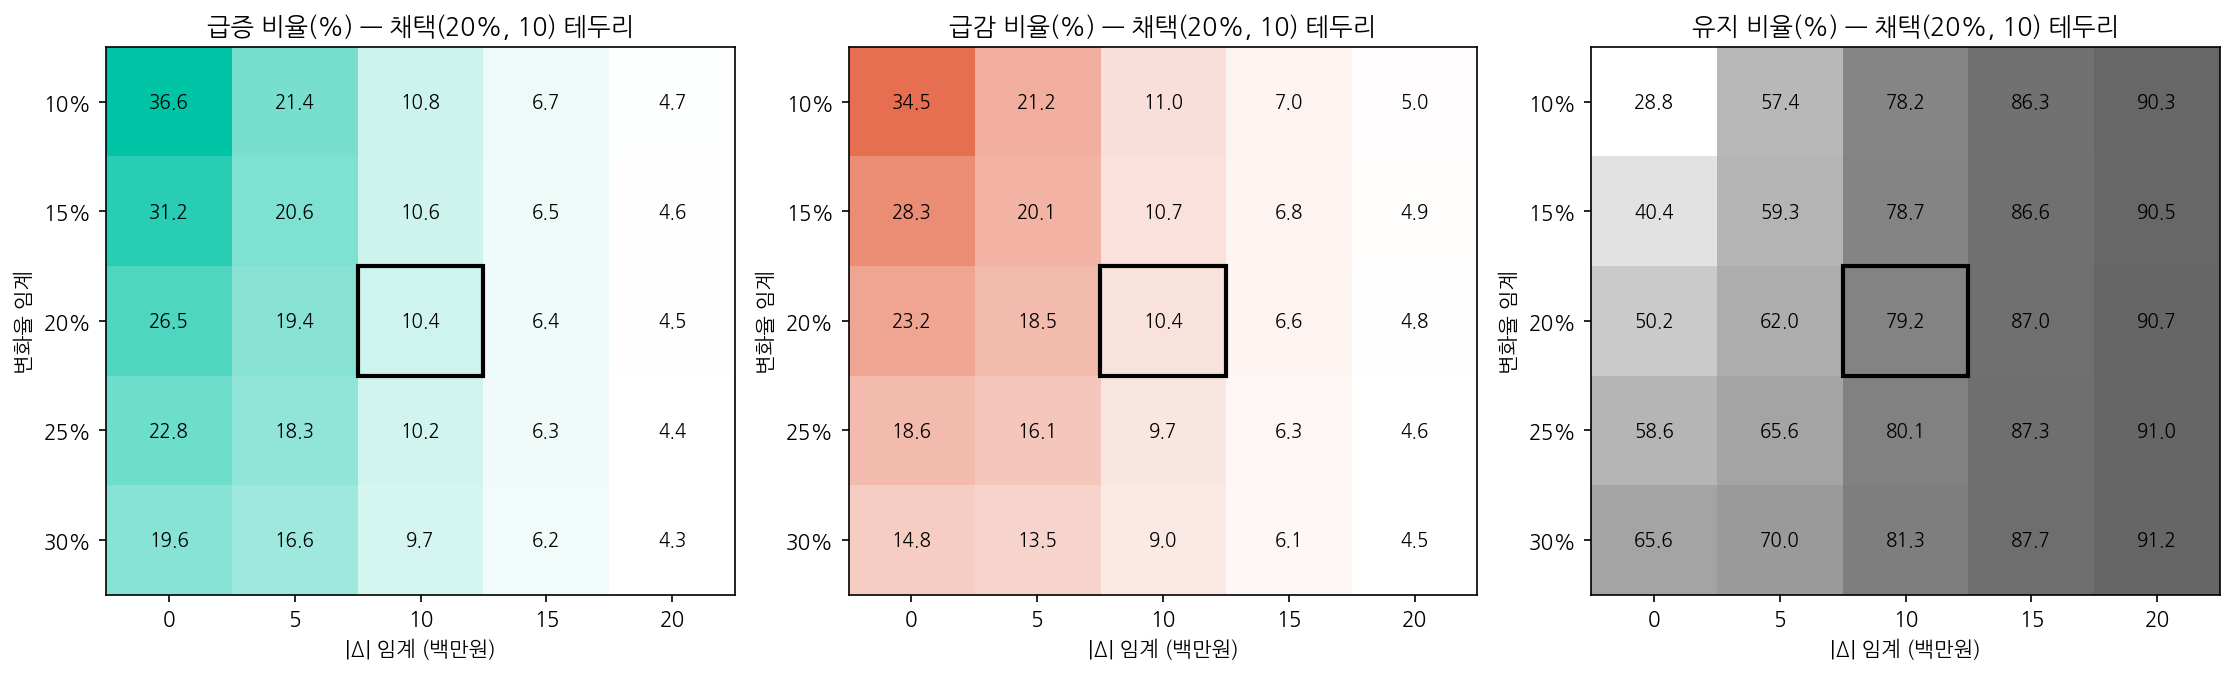

채택(20%, 10): 급증 10.4% / 급감 10.4% / 유지 79.2%  vs 목표 10/10/80
대조(20%, 0 — 절대 조건 없음): 급증 26.5% / 급감 23.2% / 유지 50.2%


In [3]:
rate_grid = [0.10, 0.15, 0.20, 0.25, 0.30]
amt_grid = [0, 5, 10, 15, 20]
rows = []
mats = {'급증': np.zeros((5, 5)), '급감': np.zeros((5, 5)), '유지': np.zeros((5, 5))}
for i, rt in enumerate(rate_grid):
    for j, at in enumerate(amt_grid):
        lab = make_label(long['delta'].values, long['변화율'].values, long['past'].values, rt, at)
        p = pd.Series(lab).value_counts(normalize=True)
        rows.append({'변화율 임계': f'{rt:.0%}', '|Δ| 임계': at,
                     '급증%': round(p.get('급증', 0)*100, 1), '급감%': round(p.get('급감', 0)*100, 1),
                     '유지%': round(p.get('유지', 0)*100, 1)})
        for lab_ in mats:
            mats[lab_][i, j] = p.get(lab_, 0) * 100
sens = pd.DataFrame(rows)
sens_wide = sens.pivot(index='변화율 임계', columns='|Δ| 임계', values=['급증%', '급감%', '유지%'])
display(sens_wide)
sens.to_csv('../outputs/tables/02_민감도_25조합.csv', index=False, encoding='utf-8-sig')

cmaps = {'급증': mpl.colors.LinearSegmentedColormap.from_list('m', ['white', IM['민트']]),
         '급감': mpl.colors.LinearSegmentedColormap.from_list('c', ['white', IM['코랄']]),
         '유지': mpl.colors.LinearSegmentedColormap.from_list('g', ['white', IM['그레이']])}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, lab_ in zip(axes, ['급증', '급감', '유지']):
    im = ax.imshow(mats[lab_], cmap=cmaps[lab_], aspect='auto')
    ax.set_xticks(range(5)); ax.set_xticklabels(amt_grid); ax.set_yticks(range(5))
    ax.set_yticklabels([f'{r:.0%}' for r in rate_grid])
    ax.set_xlabel('|Δ| 임계 (백만원)'); ax.set_ylabel('변화율 임계')
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f'{mats[lab_][i, j]:.1f}', ha='center', va='center', fontsize=9)
    ax.add_patch(plt.Rectangle((2-0.5, 2-0.5), 1, 1, fill=False, edgecolor='black', lw=2))
    ax.set_title(f'{lab_} 비율(%) — 채택(20%, 10) 테두리')
plt.tight_layout(); save_fig(fig, '02_01_민감도_히트맵.png'); plt.show()

adopt = sens[(sens['변화율 임계'] == '20%') & (sens['|Δ| 임계'] == 10)].iloc[0]
print(f"채택(20%, 10): 급증 {adopt['급증%']}% / 급감 {adopt['급감%']}% / 유지 {adopt['유지%']}%  vs 목표 10/10/80")
ctrl = sens[(sens['변화율 임계'] == '20%') & (sens['|Δ| 임계'] == 0)].iloc[0]
print(f"대조(20%, 0 — 절대 조건 없음): 급증 {ctrl['급증%']}% / 급감 {ctrl['급감%']}% / 유지 {ctrl['유지%']}%")

In [4]:
pos_mask = (long['past'] > 0) & (long['변화율'] >= 0.20) & (long['delta'] < 10)
neg_mask = (long['past'] > 0) & (long['변화율'] <= -0.20) & (long['delta'] > -10)
print(f'|Δ|≥10 조건이 걸러낸 저기저(low-base) 가짜 급증: {int(pos_mask.sum()):,}건 / 가짜 급감: {int(neg_mask.sum()):,}건')
print(f'→ 절대 조건이 없었다면 급증의 {pos_mask.sum()/(pos_mask.sum()+ (long["라벨"]=="급증").sum()):.1%}, 급감의 {neg_mask.sum()/(neg_mask.sum()+(long["라벨"]=="급감").sum()):.1%}가 저기저 노이즈였을 것')
ex = long[pos_mask].nlargest(3, '변화율')[['법인ID', '기준월', 'past', 'future', 'delta', '변화율']].copy()
ex['법인ID'] = ex['법인ID'].str[:8] + '…'
print()
print('저기저 가짜 급증 사례(변화율 상위 3):')
print(ex.round(2).to_string(index=False))
low = long[pos_mask | neg_mask]
low.to_csv('../outputs/tables/02_저기저_필터사례.csv', index=False, encoding='utf-8-sig')

|Δ|≥10 조건이 걸러낸 저기저(low-base) 가짜 급증: 1,357건 / 가짜 급감: 1,088건
→ 절대 조건이 없었다면 급증의 60.7%, 급감의 55.3%가 저기저 노이즈였을 것

저기저 가짜 급증 사례(변화율 상위 3):
     법인ID    기준월  past  future  delta    변화율
998fd158… 202409  0.00    2.20   2.20 659.00
12604ad1… 202304  0.04    9.01   8.97 224.33
998fd158… 202405  0.01    2.43   2.42 181.50


**해석 —** ① 채택 조합(±20%, |Δ|≥10)은 **10.4 / 10.4 / 79.2%**로 25개 조합 중 목표 10/10/80에 가장 근접하고 급증·급감 대칭도 확보된다. ② |Δ|=0 대조군(20%, 0)은 26.5 / 23.2 / 50.2% — 절대 조건이 없으면 샘플의 절반이 '이벤트'가 되어 급변의 희소사건 성격 자체가 무너진다. ③ **|Δ|≥10 조건이 저기저(low-base) 가짜 급증 1,357건(무조건 시 급증의 60.7%)·가짜 급감 1,088건(55.3%)을 걸러냈다** — 대표 사례: past 0.00 → future 2.20백만원(+659%)처럼 비율은 극단이지만 금액상 무의미한 변동. ④ |Δ|≥10을 고정하면 변화율 임계를 10~30%로 움직여도 급증률 10.8→9.7%로 변화폭이 1.1%p에 불과 — 채택 라벨은 변화율 임계의 미세 조정에 **강건**하다.

## 3. 기준월별 라벨 분포 + 분할(Train/Embargo/Valid/Test) 배치·저장

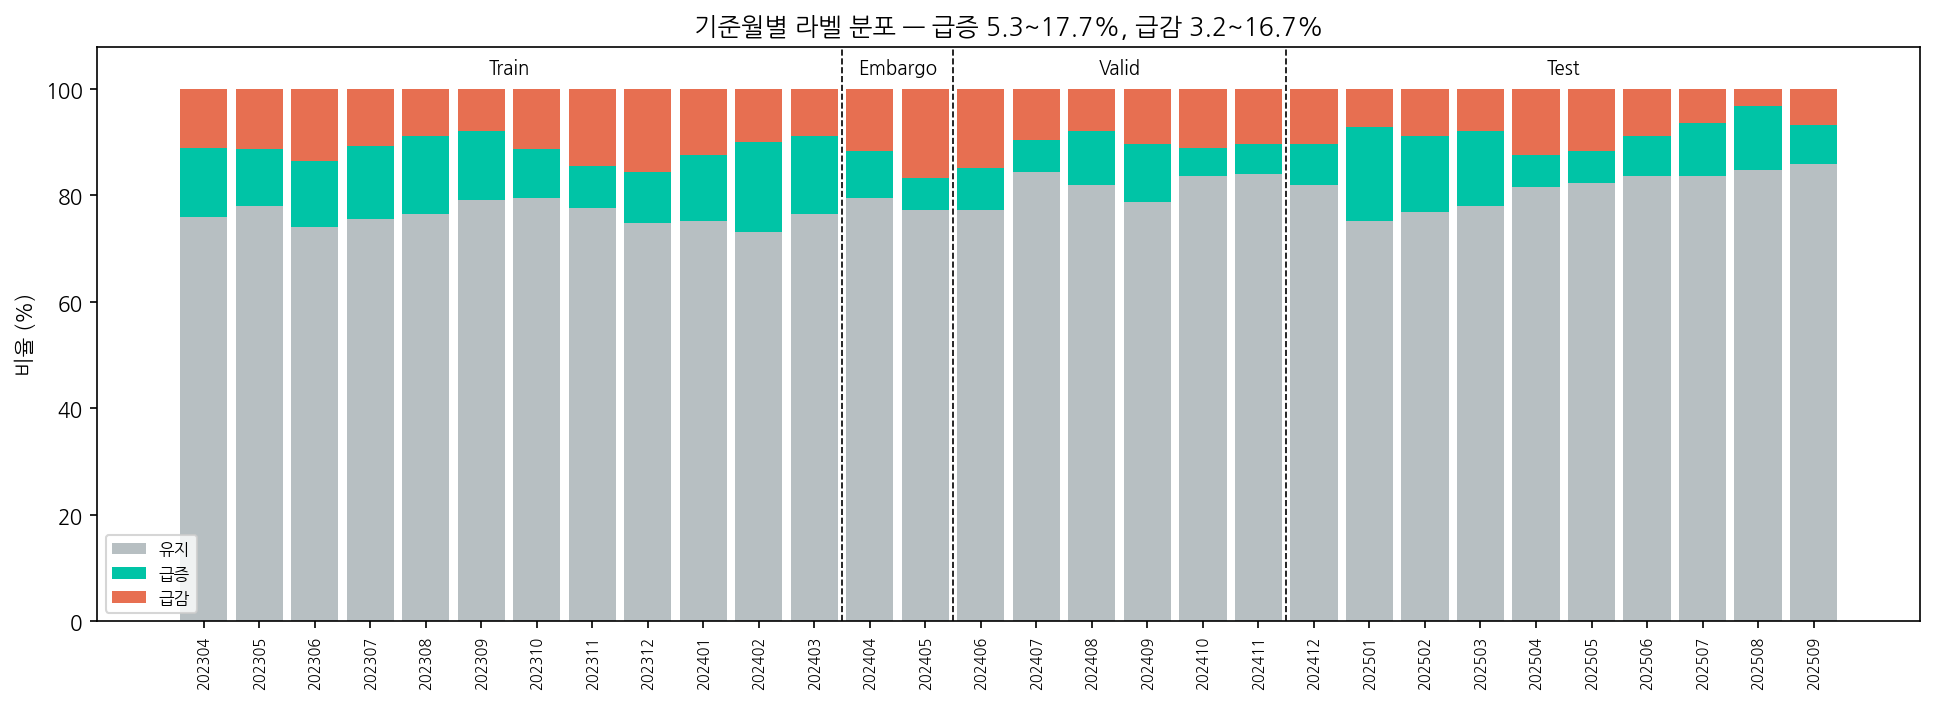

,샘플,급증pct,급감pct,유지pct
구간,,,,
Train,3384,12.4,11.3,76.3
Embargo,564,7.4,14.2,78.4
Valid,1692,7.7,10.6,81.7
Test,2820,10.3,8.3,81.4


저장: data/processed/라벨_L3.parquet — 8460 행 (구간 포함, Embargo는 학습·평가에서 제외)


In [5]:
def split_of(t):
    if 202304 <= t <= 202403: return 'Train'
    if 202404 <= t <= 202405: return 'Embargo'
    if 202406 <= t <= 202411: return 'Valid'
    return 'Test'
long['구간'] = long['기준월'].map(split_of)

monthly = pd.crosstab(long['기준월'], long['라벨'], normalize='index') * 100
fig, ax = plt.subplots(figsize=(13, 4.8))
xs = np.arange(len(monthly))
bottom = np.zeros(len(monthly))
for lab in ['유지', '급증', '급감']:
    ax.bar(xs, monthly[lab], bottom=bottom, color=LABEL_COLOR[lab], label=lab, width=0.85)
    bottom += monthly[lab].values
bounds = {'Embargo': (12, 13), 'Valid': (14, 19), 'Test': (20, 29)}
for name, (a, b) in bounds.items():
    ax.axvline(a - 0.5, color='black', ls='--', lw=0.8)
    ax.text((a + b) / 2, 103, name, ha='center', fontsize=9)
ax.text(5.5, 103, 'Train', ha='center', fontsize=9)
ax.set_xticks(xs); ax.set_xticklabels(monthly.index, rotation=90, fontsize=7)
ax.set_ylim(0, 108); ax.set_ylabel('비율 (%)'); ax.legend(loc='lower left', fontsize=8)
rng_s = monthly['급증'].max() - monthly['급증'].min()
ax.set_title(f'기준월별 라벨 분포 — 급증 {monthly["급증"].min():.1f}~{monthly["급증"].max():.1f}%, 급감 {monthly["급감"].min():.1f}~{monthly["급감"].max():.1f}%')
plt.tight_layout(); save_fig(fig, '02_02_기준월별_라벨분포.png'); plt.show()

split_tab = long.groupby('구간').agg(샘플=('라벨', 'size'),
    급증pct=('라벨', lambda s: (s == '급증').mean()*100),
    급감pct=('라벨', lambda s: (s == '급감').mean()*100),
    유지pct=('라벨', lambda s: (s == '유지').mean()*100)).reindex(['Train', 'Embargo', 'Valid', 'Test']).round(1)
display(split_tab)
split_tab.to_csv('../outputs/tables/02_라벨분포_분할별.csv', encoding='utf-8-sig')
assert split_tab.loc['Train', '샘플'] == 3384 and split_tab.loc['Valid', '샘플'] == 1692 and split_tab.loc['Test', '샘플'] == 2820

long.to_parquet('../data/processed/라벨_L3.parquet', index=False)
print('저장: data/processed/라벨_L3.parquet —', len(long), '행 (구간 포함, Embargo는 학습·평가에서 제외)')

**해석 —** 분할별 라벨 분포: **Train 12.4/11.3/76.3, Valid 7.7/10.6/81.7, Test 10.3/8.3/81.4%** (Embargo 564건은 학습·평가 모두에서 제외). 특정 시기에 라벨이 소멸하는 붕괴는 없으나, 급증 비율이 Train 12.4% → Valid 7.7% → Test 10.3%로 출렁이는 **시간 드리프트가 실재**한다 — 이것이 무작위 K-Fold를 금지하고 시간순 분할을 쓰는(§7) 실증적 이유이며, Holdout 성능이 CV보다 낮게 나올 수 있음을 미리 기대치로 잡아야 한다. 클래스 가중치는 Train 분포(12.4/11.3/76.3) 기준으로 산정한다. 라벨은 `data/processed/라벨_L3.parquet`(구간 컬럼 포함)로 저장 — 03 이후 모든 노트북은 이 파일만 로드한다.

## 4. 법인별 라벨 전이 행렬 — 급증→급감 반동 여부 (연속 기준월 t → t+1)

to,급증,유지,급감
from,,,
급증,48.5,38.2,13.3
유지,5.7,89.1,5.2
급감,6.8,47.1,46.1


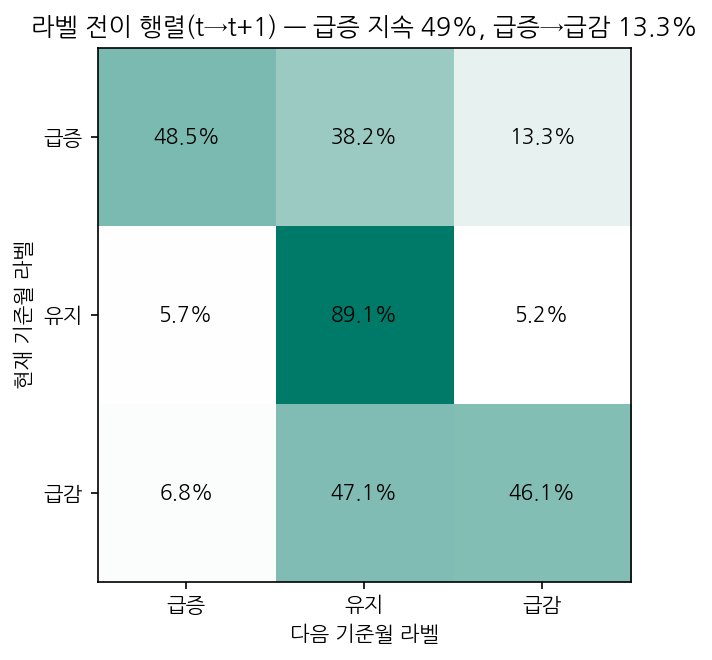

주의: 윈도우가 겹치는 연속 기준월 간 전이라 자기상관이 내재 — 지속률은 과대 해석 금지


In [6]:
long_s = long.sort_values(['법인ID', '기준월'])
lab_mat = long_s['라벨'].values.reshape(n_corp, 30)
pairs = pd.DataFrame({'from': lab_mat[:, :-1].ravel(), 'to': lab_mat[:, 1:].ravel()})
trans = pd.crosstab(pairs['from'], pairs['to'], normalize='index').loc[['급증', '유지', '급감'], ['급증', '유지', '급감']] * 100
display(trans.round(1))
trans.to_csv('../outputs/tables/02_전이행렬.csv', encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(trans.values, cmap=mpl.colors.LinearSegmentedColormap.from_list('t', ['white', IM['딥민트']]))
ax.set_xticks(range(3)); ax.set_xticklabels(trans.columns); ax.set_yticks(range(3)); ax.set_yticklabels(trans.index)
ax.set_xlabel('다음 기준월 라벨'); ax.set_ylabel('현재 기준월 라벨')
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{trans.values[i, j]:.1f}%', ha='center', va='center')
ax.set_title(f'라벨 전이 행렬(t→t+1) — 급증 지속 {trans.loc["급증","급증"]:.0f}%, 급증→급감 {trans.loc["급증","급감"]:.1f}%')
plt.tight_layout(); save_fig(fig, '02_03_라벨_전이행렬.png'); plt.show()
print('주의: 윈도우가 겹치는 연속 기준월 간 전이라 자기상관이 내재 — 지속률은 과대 해석 금지')

**해석 —** 급증의 48.5%는 다음 기준월에도 급증으로 지속되고(윈도우 3개월 중첩에 의한 자기상관 포함 — 과대 해석 금지), 급증→급감 직행 반전은 13.3%에 그친다 — 급증은 1개월성 스파이크가 아니라 **수 개월 지속되는 국면(regime)** 성격이다. 급감도 지속률 46.1%로 대칭적이며, **급감→급증 회복은 6.8%뿐** — 급감은 방치 시 자연 회복이 드물어 조기 개입(이탈 방지 트리거, 주제1 프레이밍)의 가치가 수치로 정당화된다. 유지의 89.1%는 유지에 머물러 다수 클래스의 관성도 확인된다.

## 5. 이벤트 스터디 — 급증·급감 t0 기준 ±6개월, 은행 관계 지표의 평균 궤적 (유지군 대비)

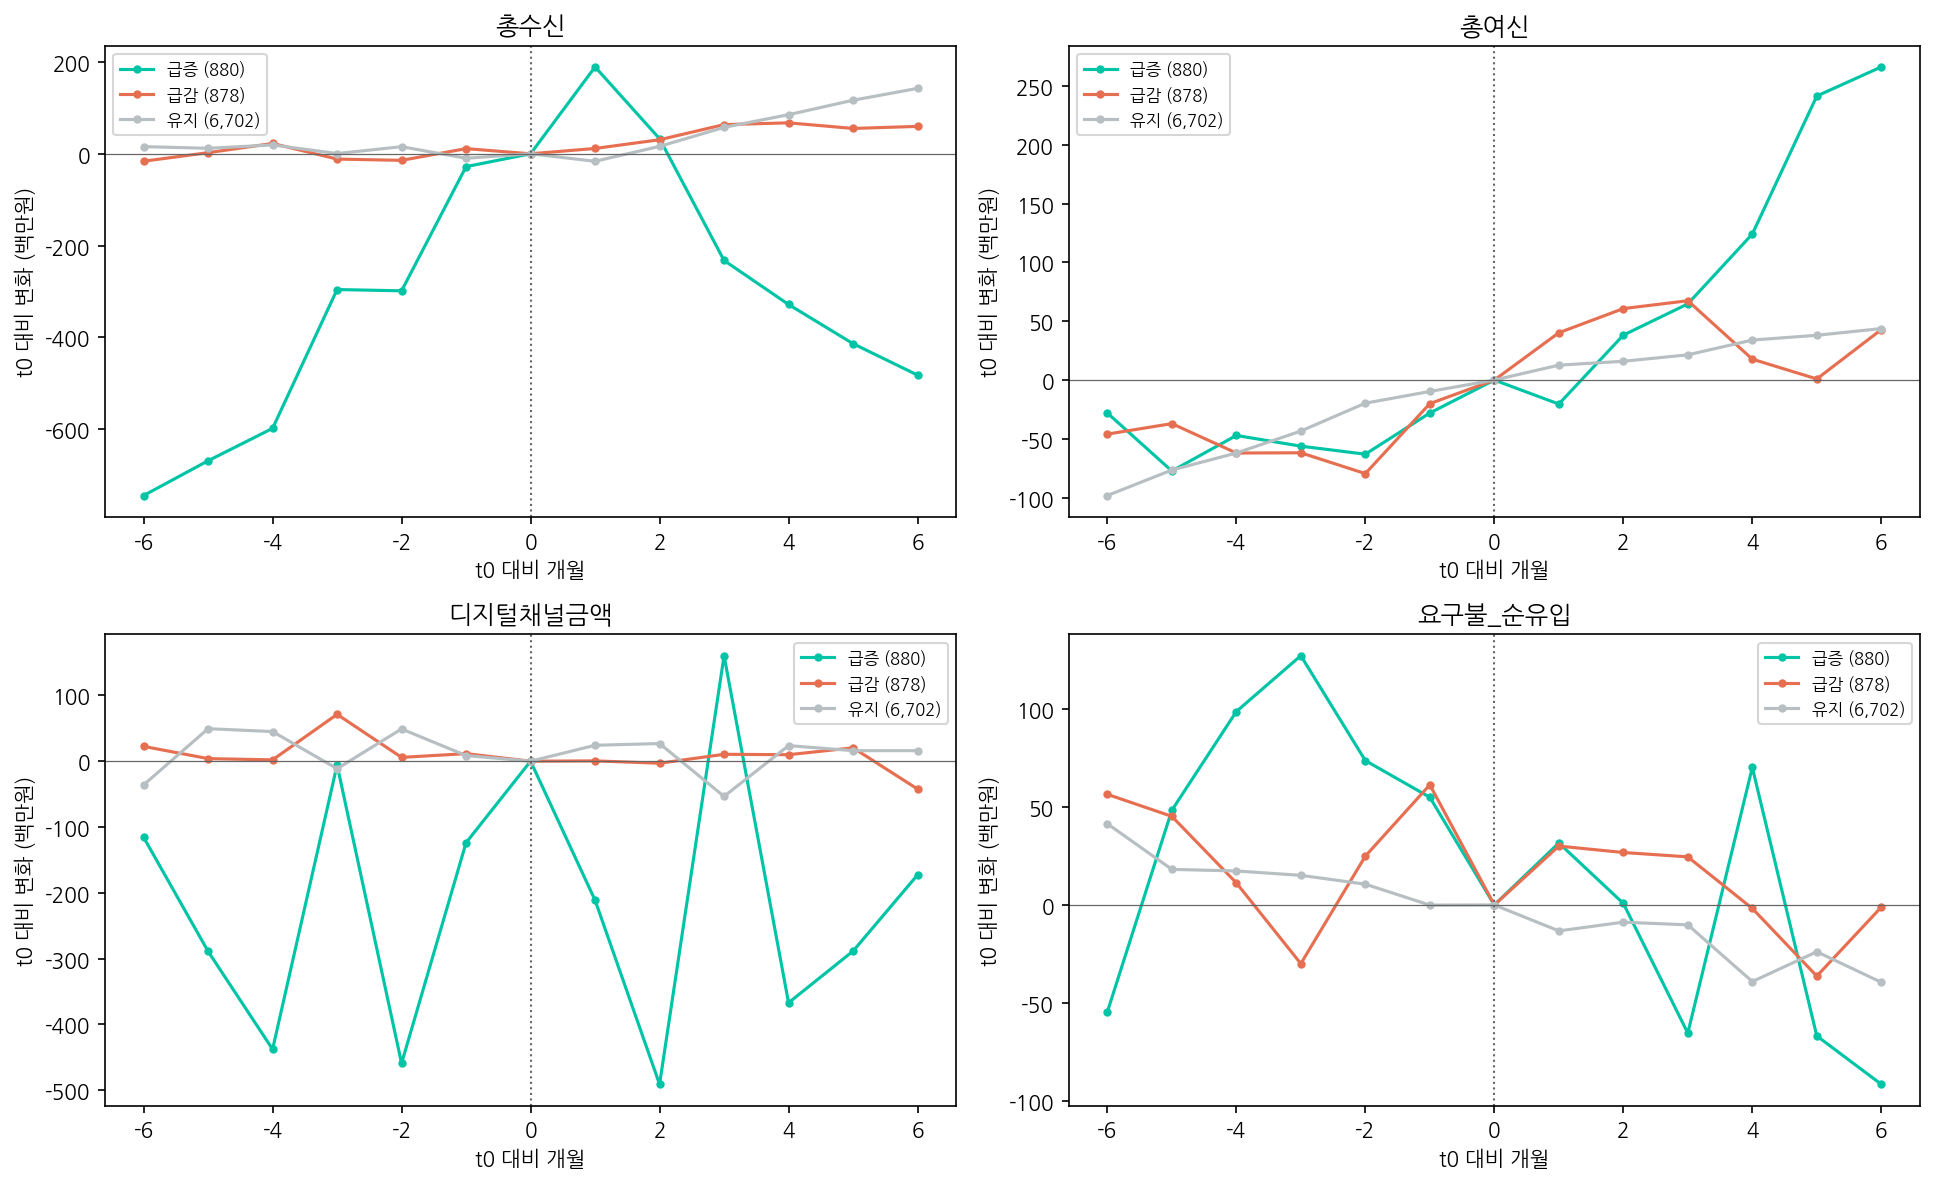

총수신: t0+6 평균 변화 — 급증 -482.3 / 급감 +59.7 / 유지 +142.5백만원
총여신: t0+6 평균 변화 — 급증 +266.3 / 급감 +42.9 / 유지 +43.8백만원
디지털채널금액: t0+6 평균 변화 — 급증 -172.7 / 급감 -42.3 / 유지 +16.0백만원
요구불_순유입: t0+6 평균 변화 — 급증 -91.5 / 급감 -1.1 / 유지 -39.5백만원


In [7]:
sub['총수신'] = sub[['요구불예금잔액', '거치식예금잔액', '적립식예금잔액', '수익증권잔액', '신탁잔액']].sum(axis=1)
sub['총여신'] = sub['여신_운전자금대출잔액'] + sub['여신_시설자금대출잔액']
sub['디지털채널금액'] = sub['인터넷뱅킹거래금액'] + sub['스마트뱅킹거래금액']
sub['요구불_순유입'] = sub['요구불입금금액'] - sub['요구불출금금액']
metrics = ['총수신', '총여신', '디지털채널금액', '요구불_순유입']
mat = {m: sub.pivot(index=ID, columns=YM, values=m).reindex(index=l3_ids, columns=months).values for m in metrics}

corp_idx = np.repeat(np.arange(n_corp), 30)
t_idx = np.tile(np.array(T_IDXS), n_corp)
lab_arr = long_s['라벨'].values
offsets = range(-6, 7)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
event_stats = {}
for ax, m in zip(axes.ravel(), metrics):
    for lab in ['급증', '급감', '유지']:
        sel = lab_arr == lab
        ci, ti = corp_idx[sel], t_idx[sel]
        ys = []
        for k in offsets:
            ok = (ti + k >= 0) & (ti + k <= 35)
            ys.append(np.nanmean(mat[m][ci[ok], ti[ok] + k] - mat[m][ci[ok], ti[ok]]))
        ax.plot(list(offsets), ys, marker='o', ms=3, color=LABEL_COLOR[lab], label=f'{lab} ({sel.sum():,})')
        event_stats[(m, lab)] = ys
    ax.axvline(0, color=IM['그레이'], ls=':', lw=1)
    ax.axhline(0, color=IM['그레이'], lw=0.6)
    ax.set_title(m); ax.set_xlabel('t0 대비 개월'); ax.set_ylabel('t0 대비 변화 (백만원)')
    ax.legend(fontsize=8)
plt.tight_layout(); save_fig(fig, '02_04_이벤트스터디.png'); plt.show()

for m in metrics:
    s6, p6, k6 = event_stats[(m, '급증')][-1], event_stats[(m, '급감')][-1], event_stats[(m, '유지')][-1]
    print(f'{m}: t0+6 평균 변화 — 급증 {s6:+,.1f} / 급감 {p6:+,.1f} / 유지 {k6:+,.1f}백만원')

**해석 —** 01_EDA §8에서 동월(MoM) 상관이 0이었던 것과 달리, **시차를 두면 급증·급감은 은행 관계 변화와 뚜렷이 동행한다.** 급증 후 6개월(t0+6, 유지군 대비): **총수신 −482백만원(유지 +143) / 총여신 +266(유지 +44의 약 6배) / 디지털 −173 / 요구불 순유입 −92** — 카드 급증 법인은 예치금을 소진하며 여신을 확대하는 **자금 수요·지출 확대 국면**에 진입해 있다. 급감 후 6개월은 총수신 +60(유지의 절반 이하)·총여신 +43(유지와 동일)·디지털 −42로 관계 성장이 전반적으로 둔화된다. **비즈니스 함의:** 급증 탐지 = 운전자금 대출·한도 증액 수요의 선행 신호(선제 여신 제안 시점), 급감 탐지 = 관계 둔화의 조기 경보(이탈 방지 개입 시점). ※ 한계: 평균 기반 궤적이라 대형 법인의 영향이 크며, 금액 라운딩·가상 데이터 한계가 동일하게 적용된다.

## 6. 라벨 × 규모·변동성 사분면 교차 — 01_EDA §9 가설("라벨은 고변동 사분면에 집중") 검증

주의: 사분면은 전 기간(2023-02~2025-12) 통계로 정의한 **EDA 진단용 축**이다. 미래 정보를 포함하므로 피처로는 사용 금지(§7).

In [8]:
idx_0302 = months.index(202302)
cm = card_mat[:, idx_0302:]
c_mean, c_std = cm.mean(axis=1), cm.std(axis=1)
cv = np.where(c_mean > 0, c_std / np.where(c_mean > 0, c_mean, 1), np.nan)
mx, my = np.median(c_mean), np.median(cv)
quad = np.select([(c_mean >= mx) & (cv >= my), (c_mean >= mx) & (cv < my), (c_mean < mx) & (cv >= my)],
                 ['고액·고변동', '고액·안정', '저액·고변동'], default='저액·안정')
quad_map = dict(zip(l3_ids, quad))
long_s['사분면'] = long_s['법인ID'].map(quad_map)

qt = pd.crosstab(long_s['사분면'], long_s['라벨'], normalize='index') * 100
qt['이벤트(급증+급감)'] = qt['급증'] + qt['급감']
qt = qt.loc[['고액·고변동', '저액·고변동', '고액·안정', '저액·안정'], ['급증', '급감', '유지', '이벤트(급증+급감)']]
display(qt.round(1))
qt.to_csv('../outputs/tables/02_라벨x사분면.csv', encoding='utf-8-sig')
hi = qt.loc[['고액·고변동', '저액·고변동'], '이벤트(급증+급감)'].mean()
lo = qt.loc[['고액·안정', '저액·안정'], '이벤트(급증+급감)'].mean()
print(f'고변동 사분면 이벤트율 평균 {hi:.1f}% vs 안정 사분면 {lo:.1f}% — ×{hi/lo:.1f}배')

라벨,급증,급감,유지,이벤트(급증+급감)
사분면,,,,
고액·고변동,21.9,21.6,56.5,43.5
저액·고변동,8.3,10.5,81.3,18.7
고액·안정,10.2,8.2,81.6,18.4
저액·안정,1.4,1.4,97.2,2.8


고변동 사분면 이벤트율 평균 31.1% vs 안정 사분면 10.6% — ×2.9배


**해석 —** 01_EDA §9의 가설이 확정됐다: 이벤트율(급증+급감)이 **고액·고변동 43.5% > 저액·고변동 18.7% ≈ 고액·안정 18.4% ≫ 저액·안정 2.8%**, 고변동 사분면 평균 31.1% vs 안정 사분면 10.6%로 **×2.9배**다. 시사점: ① 변동성 피처(카드사용_6개월표준편차·변동계수)가 1급 예측 변수일 것 ② 저액·안정 사분면은 이벤트가 사실상 없어(2.8%) 모델이 이 군을 '유지'로 안전하게 분류하는 것만으로 유지 recall이 확보된다. 단, 이 사분면은 전 기간(미래 포함) 통계로 만든 진단 축이므로 **피처로는 절대 사용 금지** — 03에서는 t 이하 윈도우 변동성(6M)만 파생한다(§7).

## 7. 결론 — 02 산출 요약과 03 착수 조건

**확정된 것:** ① 라벨 8,460건 = 급증 880(10.4%) / 급감 878(10.4%) / 유지 6,702(79.2%) — 목표 10/10/80 부합, 25조합 민감도로 정당화 완료. ② past=0(50건, 0.59%)은 Δ 단독 기본안 적용. ③ 분할 배치·저장 완료(`라벨_L3.parquet`): Train 3,384 / Embargo 564 제외 / Valid 1,692 / Test 2,820. ④ 급증·급감의 비즈니스 가치 근거 확보 — 국면 지속성(급증 지속 48.5%, 급감 자연회복 6.8%뿐), 이벤트 스터디(급증 후 총수신 −482·총여신 +266 vs 유지군), 고변동 사분면 이벤트 집중(×2.9).

**03_피처엔지니어링 착수 조건:** ① 구간형 29개 서수 인코딩 맵 생성·assert 게이트(§8-2) ② 파생변수 사전(문헌 웹 검증 포함, §9) ③ `여신한도_소진율` 분모 0 규칙(전무군 여신한도=0 이슈, 01_EDA §10) ④ 이상 월(2023-08 등급, 2025-01 전담) 플래그 처리 상의(§15) ⑤ 사업장 결측(474개 법인) '미상' 처리 상의 ⑥ **Valid/Test·Embargo 경계 팀원 대조(미결 — Train만 확정)**.